In [1]:
import obspy
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import pandas as pd
import seisbench.models as sbm
from obspy import Stream
from obspy.signal.trigger import recursive_sta_lta, trigger_onset

In [2]:
# params (from David)

# IRIS is now EARTHSCOPE, either work though
SOURCE = 'IRIS'
NETWORK = 'AV'
STATION = 'SSLS'
LOCATION = ''
CHANNEL = 'BH*'

START = UTCDateTime('2025-11-01T00:00:00')
# get xx secs of data 
END = START + 1800

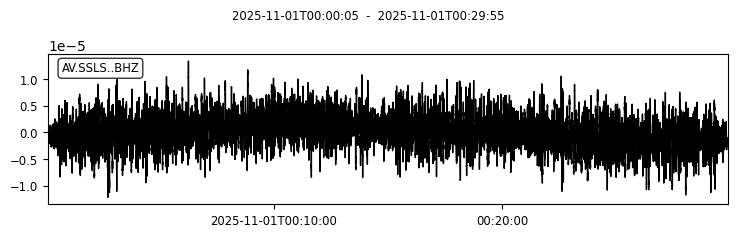

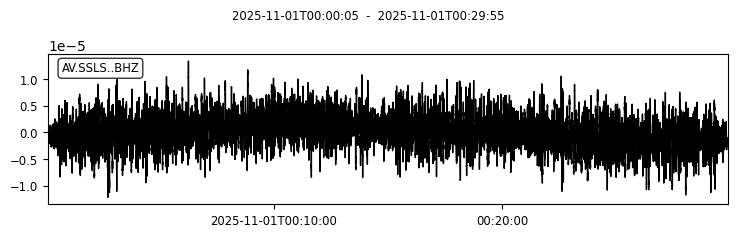

In [3]:
# get data 
client = Client(SOURCE)

stream = client.get_waveforms(NETWORK, STATION, LOCATION, CHANNEL, START, END)

# convert to velocity (remove instrument response)
inv = client.get_stations(network="AV", station="SSLS", level="response")
stream.remove_response(inventory=inv, output="VEL")

# # plot data
# Select BHZ
tr = stream.select(channel="BHZ")[0]
tr_trimmed = tr.copy()
tr_trimmed = tr_trimmed.trim(starttime=tr.stats.starttime + 5, endtime=tr.stats.endtime - 5)

tr_trimmed.plot()

In [4]:
# filter data
# raw = stream.select(channel="BHZ")[0].copy()

# Create filtered version
filtered = tr.copy()
filtered.detrend("demean") # center around 0, essentially get rid of DC offeset
filtered.detrend("linear") # get rid of low frequency instrumental drift (like if there was a bit of a slope, removes that linear trend)
filtered.taper(max_percentage=0.03) # helps reduce edge effects
filtered.filter(
    "bandpass",
    freqmin=0.5,
    freqmax=8.0,
    corners=2,
    zerophase=True
)


AV.SSLS..BHZ | 2025-11-01T00:00:00.000000Z - 2025-11-01T00:30:00.000000Z | 50.0 Hz, 90001 samples

In [5]:
# load model through seisbench and get denoised data
model = sbm.DeepDenoiser.from_pretrained("original")

filtered_stream = Stream([filtered])
denoised_filtered = model.annotate(filtered_stream)

/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.loa

In [6]:
# trim and get times
filtered_trimmed = filtered.copy()
filtered_trimmed.trim(
    starttime=filtered_trimmed.stats.starttime,
    endtime=filtered_trimmed.stats.endtime - 5
)

denoised_filtered_trimmed = denoised_filtered[0].copy()
denoised_filtered_trimmed.trim(
    starttime=denoised_filtered_trimmed.stats.starttime,
    endtime=denoised_filtered_trimmed.stats.endtime - 5
)

times = tr_trimmed.times("matplotlib")
times_filtered = filtered_trimmed.times("matplotlib")
times_denoised = denoised_filtered_trimmed.times("matplotlib")

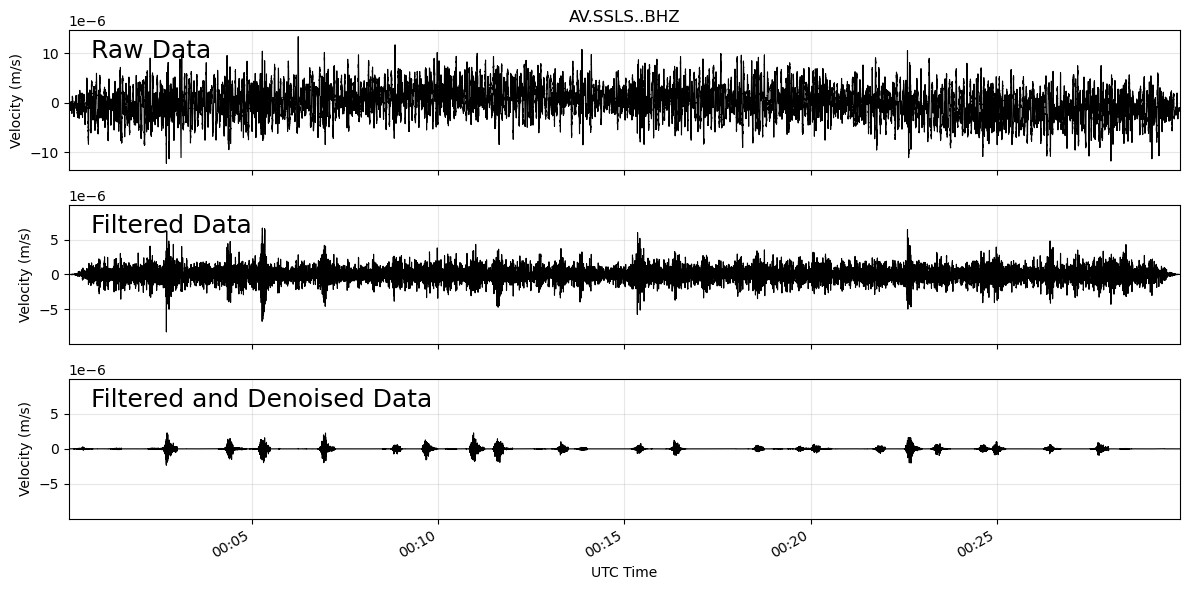

In [7]:
# plot all three together, raw - filtered - denoised
# denoised = denoised
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

axes[0].plot(times, tr_trimmed.data, linewidth=0.8, color="black")
axes[0].set_title(tr.id)
axes[0].set_ylabel("Velocity (m/s)")
# axes[0].set_ylim(-8.5e-6, 8.5e-6)
# axes[0].set_yticks([-5e-6, 0, 5e-6])
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[0].text(
    0.02, 0.80, "Raw Data",
    transform=axes[0].transAxes,
    fontsize=18
)

axes[1].plot(times_filtered, filtered_trimmed.data, linewidth=0.8, color="black")
axes[1].set_ylabel("Velocity (m/s)")
axes[1].set_ylim(-10e-6, 10e-6)
axes[1].set_yticks([-5e-6, 0, 5e-6])
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[1].text(
    0.02, 0.80, "Filtered Data",
    transform=axes[1].transAxes,
    fontsize=18
)

axes[2].plot(
    times_denoised,
    denoised_filtered_trimmed,
    linewidth=0.8,
    color="black"
)
axes[2].set_ylabel("Velocity (m/s)")
axes[2].set_ylim(-10e-6, 10e-6)
axes[2].set_yticks([-5e-6, 0, 5e-6])
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[2].text(
    0.02, 0.80, "Filtered and Denoised Data",
    transform=axes[2].transAxes,
    fontsize=18
)

for ax in axes:
    ax.set_xlim(times[0], times[-1])
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel("UTC Time")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [8]:
# sta/lta on filtered, denoised, and filtered + denoised data

def run_sta_lta(
    trace,
    sta_seconds=1.0,
    lta_seconds=10.0,
    trigger_on=3.0,
    trigger_off=1.5,
    startup_seconds=5.0
):
    fs = trace.stats.sampling_rate

    nsta = int(sta_seconds * fs)
    nlta = int(lta_seconds * fs)

    cft = recursive_sta_lta(trace.data, nsta, nlta)

    # Don't allow triggers during STA/LTA startup
    startup_samples = int(startup_seconds * fs)
    cft_for_trigger = cft.copy()
    cft_for_trigger[:startup_samples] = 0

    triggers = trigger_onset(
        cft_for_trigger,
        trigger_on,
        trigger_off
    )

    return cft, triggers

In [9]:
# run it 

# Parameters
sta_seconds = 1
lta_seconds = 10
trigger_on = 3
trigger_off = 1.5
startup_seconds = 120

# filtered
cft_filtered, triggers_filtered = run_sta_lta(
    filtered_trimmed,
    sta_seconds=sta_seconds,
    lta_seconds=lta_seconds,
    trigger_on=trigger_on,
    trigger_off=trigger_off,
    startup_seconds=startup_seconds)

# denoised
cft_filtered_denoised, triggers_filtered_denoised = run_sta_lta(
    denoised_filtered_trimmed,
    sta_seconds=sta_seconds,
    lta_seconds=lta_seconds,
    trigger_on=trigger_on,
    trigger_off=trigger_off,
    startup_seconds=startup_seconds)

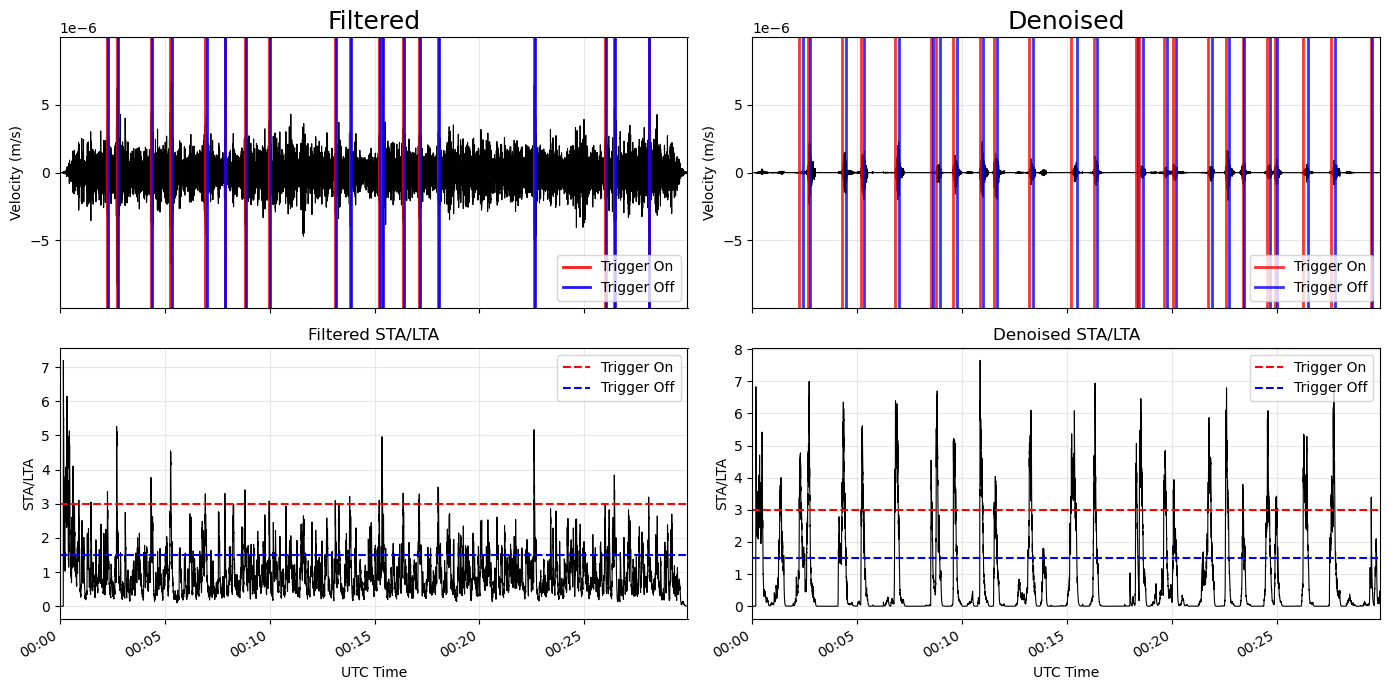

In [10]:
# plot

# create time arrays
times_filtered = filtered_trimmed.times("matplotlib")
times_filtered_denoised = denoised_filtered_trimmed.times("matplotlib")

# y axis ticks
waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 7),
    sharex="col"
)

ax = axes[0, 0]

ax.plot(
    times_filtered,
    filtered_trimmed.data,
    linewidth=0.8,
    color="black"
)

ax.set_title("Filtered", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))

# Plot trigger start/end lines
for i, (on, off) in enumerate(triggers_filtered):

    # Trigger ON = red
    ax.axvline(
        times_filtered[on],
        color="red",
        linewidth=2,
        alpha=0.9,
        label="Trigger On" if i == 0 else None
    )

    # Trigger OFF = blue
    ax.axvline(
        times_filtered[off],
        color="blue",
        linewidth=2,
        alpha=0.9,
        label="Trigger Off" if i == 0 else None
    )

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]

ax.plot(
    times_filtered_denoised,
    denoised_filtered_trimmed.data,
    linewidth=0.8,
    color="black"
)

ax.set_title("Denoised", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, 6))

for i, (on, off) in enumerate(triggers_filtered_denoised):

    ax.axvline(
        times_filtered_denoised[on],
        color="red",
        linewidth=2,
        alpha=0.8,
        label="Trigger On" if i == 0 else None
    )

    ax.axvline(
        times_filtered_denoised[off],
        color="blue",
        linewidth=2,
        alpha=0.8,
        label="Trigger Off" if i == 0 else None
    )

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]

ax.plot(
    times_filtered,
    cft_filtered,
    linewidth=0.8,
    color="black"
)

# Threshold lines
ax.axhline(
    trigger_on,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Trigger On"
)

ax.axhline(
    trigger_off,
    color="blue",
    linestyle="--",
    linewidth=1.5,
    label="Trigger Off"
)

ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Filtered STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]

ax.plot(
    times_filtered_denoised,
    cft_filtered_denoised,
    linewidth=0.8,
    color="black"
)

# Threshold lines
ax.axhline(
    trigger_on,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Trigger On"
)

ax.axhline(
    trigger_off,
    color="blue",
    linestyle="--",
    linewidth=1.5,
    label="Trigger Off"
)

ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Denoised STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:

    ax.margins(x=0)

    ax.xaxis.set_major_locator(
        mdates.MinuteLocator(interval=5)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M")
    )


fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [12]:
# get numbers for comparison
n_events_filtered = len(triggers_filtered)

n_events_filtered_denoised = len(triggers_filtered_denoised)

print(f"Number of events in filtered data: {n_events_filtered}")
print(f"Number of events in denoised data: {n_events_filtered_denoised}")

Number of events in filtered data: 19
Number of events in denoised data: 25


Traceback (most recent call last):
  File "/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/runpy.py", line 194, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/Users/amelega/miniconda3/envs/deepdenoiser/

In [54]:
# SNR

def calculate_whole_period_snr(trace, triggers):

    data = trace.data.astype(float)

    # Boolean mask:
    # True = event/signal
    # False = noise
    signal_mask = np.zeros(len(data), dtype=bool)

    # Mark all STA/LTA-triggered portions as signal
    for on, off in triggers:

        signal_mask[on:off] = True

    # Separate signal and noise
    signal_data = data[signal_mask]
    noise_data = data[~signal_mask] # dont need ot use everything that isnt signal here

    # RMS
    signal_rms = np.sqrt(np.mean(signal_data**2))
    noise_rms = np.sqrt(np.mean(noise_data**2))

    # SNR in dB
    snr_db = 20 * np.log10(signal_rms / noise_rms)

    return signal_rms, noise_rms, snr_db

# filtered
filtered_signal_rms, filtered_noise_rms, filtered_snr_db = (
    calculate_whole_period_snr(
        filtered_trimmed,
        triggers_filtered))


# denoised
denoised_signal_rms, denoised_noise_rms, denoised_snr_db = (
    calculate_whole_period_snr(
        denoised_filtered_trimmed,
        triggers_filtered_denoised))

In [55]:
print("WHOLE-PERIOD SNR")
print("----------------")

print(f"Filtered:")
print(f"  Signal RMS: {filtered_signal_rms:.6e}")
print(f"  Noise RMS:  {filtered_noise_rms:.6e}")
print(f"  SNR:        {filtered_snr_db:.2f} dB")

print()

print(f"Denoised:")
print(f"  Signal RMS: {denoised_signal_rms:.6e}")
print(f"  Noise RMS:  {denoised_noise_rms:.6e}")
print(f"  SNR:        {denoised_snr_db:.2f} dB")

WHOLE-PERIOD SNR
----------------
Filtered:
  Signal RMS: 2.583474e-06
  Noise RMS:  1.236417e-06
  SNR:        6.40 dB

Denoised:
  Signal RMS: 1.188217e-06
  Noise RMS:  4.403806e-07
  SNR:        8.62 dB


In [63]:
# Create event catalog from existing calculated values

event_catalog = pd.DataFrame([{
    "time_start": filtered_trimmed.stats.starttime.strftime("%H:%M:%S"),
    "time_end": filtered_trimmed.stats.endtime.strftime("%H:%M:%S"),

    "num_events_filtered": n_events_filtered,
    "num_events_denoised": n_events_filtered_denoised,

    "snr_filtered (db)": round(filtered_snr_db, 3),
    "snr_denoised(db)": round(denoised_snr_db, 3),

    "snr_percent_increase": round(
        (
            (denoised_snr_db - filtered_snr_db)
            / filtered_snr_db
        ) * 100,
        3
    )
}])

event_catalog

,time_start,time_end,num_events_filtered,num_events_denoised,snr_filtered (db),snr_denoised(db),snr_percent_increase
0,00:04:55,00:06:00,11,8,6.401,8.621,34.692


In [ ]:
tr_orig = stream.select(channel="BHZ")[0]
tr_den = predictions.select(channel="DeepDenoiser_BHZ")[0]

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Original
tr_orig.spectrogram(
    axes=ax[0],
    wlen=2.0,      # 2-second window
    per_lap=0.9,   # 90% overlap
    dbscale=True,
    cmap="viridis"
)
ax[0].set_title("Original Signal")
# ax[0].set_ylim(0, 20)   # Focus on frequencies relevant to volcanic tremor

# Denoised
tr_den.spectrogram(
    axes=ax[1],
    wlen=2.0,
    per_lap=0.9,
    dbscale=True,
    cmap="viridis"
)
ax[1].set_title("DeepDenoiser Output")
# ax[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()

In [ ]:
import inspect

print(inspect.signature(model.annotate))
help(model.annotate)


In [ ]:
# normalize and compare for sanity check

orig = tr_orig.data / np.max(np.abs(tr_orig.data))
den = tr_den.data / np.max(np.abs(tr_den.data))

plt.figure(figsize=(12, 3))
plt.plot(tr_orig.times(), orig, label="Original", alpha=0.6)
plt.plot(tr_den.times(), den, label="Denoised", alpha=0.8)
plt.legend()
plt.grid(True)

In [ ]:
# lets try denoising 7 minutes but trimming back to 5 to confirm whether
# its edge artifacts or something else

# get data
stream7 = client.get_waveforms(NETWORK, STATION, LOCATION, CHANNEL, START, START + 420)
stream7.remove_response(inventory=inv, output="VEL")

# get predictions
predictions7 = model.annotate(stream7)

# trim
trim_start = UTCDateTime("2023-07-14T08:31:00")
trim_end   = UTCDateTime("2023-07-14T08:36:00")

stream7.trim(trim_start, trim_end)
predictions7.trim(trim_start, trim_end)

# plot normalized
tr_orig7 = stream7.select(channel="BHZ")[0]
tr_den7 = predictions7.select(channel="DeepDenoiser_BHZ")[0]
orig7 = tr_orig7.data / np.max(np.abs(tr_orig7.data))
den7= tr_den7.data / np.max(np.abs(tr_den7.data))

plt.figure(figsize=(12, 3))
plt.plot(tr_orig7.times(), orig7, label="Original", alpha=0.6)
plt.plot(tr_den7.times(), den7, label="Denoised", alpha=0.8)
plt.title("Normalized Plot of Trimmed Original and Denoised Signals")
plt.legend()
plt.grid(True)

In [ ]:
# plot signal and denoised signal together after trim

trace7 = stream7.select(channel="BHZ")[0]
denoised_trace7 = predictions7.select(channel="DeepDenoiser_BHZ")[0]

plt.figure(figsize=(12, 4))

plt.plot(trace7.times(), trace7.data,
         label="Original", linewidth=0.8)

plt.plot(denoised_trace7.times(), denoised_trace7.data,
         label="DeepDenoiser", color="tab:orange", linewidth=1.0)

plt.title("Original and DeepDenoiser Signals")
plt.xlabel("Time (s)")
plt.ylabel("Ground velocity (m/s)")
plt.legend()
plt.grid(True)
plt.margins(x=0)
plt.tight_layout()
plt.show()

In [ ]:
# use 7 minute data so we already trimmed
trace_50 = stream7.select(channel="BHZ")[0].copy()
trace_100 = trace_50.copy()
trace_100.resample(100.0)

# plot first 30 seconds
plt.figure(figsize=(12,4))
plt.plot(trace_50.times(), trace_50.data/np.max(np.abs(trace_50.data)), label="50Hz")
plt.plot(trace_100.times(), trace_100.data/np.max(np.abs(trace_100.data)), label="100Hz")
plt.legend
plt.grid(True)


They look the same, no sign of ringing or edge distortions. Lets see if anything changes if we just resample first. 

In [ ]:
print(model.sampling_rate)
print(model.default_args)

In [ ]:
# manually upsample and run the model
stream_100 = stream7.copy()
stream_100.resample(sampling_rate=100,no_filter=True)

predictions_100 = model.annotate(stream_100)

In [ ]:
predictions_100.plot()